# 🚀 AdVision AI – Smart Advertisement Click Prediction System

---

## 📌 Business Problem

Digital marketing companies spend millions on advertisements every year. However, not every user clicks on an advertisement.

Displaying advertisements to users who are unlikely to click increases advertising costs and reduces marketing efficiency.

---

## 🎯 Project Objective

The objective of this project is to build a Machine Learning model that predicts whether a user will click on an advertisement based on demographic and behavioral information.

---

## 💼 Business Value

A successful prediction model can help businesses:

- Reduce unnecessary advertising costs
- Improve advertisement targeting
- Increase Click-Through Rate (CTR)
- Improve Return on Investment (ROI)

---

## 🤖 Machine Learning Task

This is a **Binary Classification** problem.

Target Variable:

- **0 → User did not click the advertisement**
- **1 → User clicked the advertisement**

---

## 🛠 Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-Learn
- Logistic Regression

# 📂 Dataset Understanding

The dataset contains demographic and behavioral information about website users.

Each row represents one user, while each column describes a specific characteristic of that user.

The goal is to use these features to predict whether the user will click on an online advertisement.

### Target Variable

**Clicked on Ad**

- 0 → User did not click the advertisement
- 1 → User clicked the advertisement


# 📚 Importing Required Libraries

Machine Learning projects rely on specialized Python libraries for data analysis, visualization, and model building.

Each library used in this project has a specific purpose, such as loading data, creating visualizations, or training a machine learning model.


In [2]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# 📥 Loading the Dataset

The dataset is stored in CSV (Comma-Separated Values) format.

In this step, we load the dataset into a Pandas DataFrame so that it can be explored, analyzed, and used for building a Machine Learning model.

In [3]:
from google.colab import files

uploaded = files.upload()

Saving advertising.csv to advertising.csv


In [4]:
df = pd.read_csv("advertising.csv")

In [5]:
df.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
0,68.95,35,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,2016-03-27 00:53:11,0
1,80.23,31,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,2016-04-04 01:39:02,0
2,69.47,26,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,2016-03-13 20:35:42,0
3,74.15,29,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,2016-01-10 02:31:19,0
4,68.37,35,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,2016-06-03 03:36:18,0


# 🔍 Initial Data Exploration

Before preprocessing or training a Machine Learning model, it is important to inspect the dataset.

This helps us understand:

- Dataset structure
- Data types
- Missing values
- Basic statistical information

In [6]:
df.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
0,68.95,35,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,2016-03-27 00:53:11,0
1,80.23,31,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,2016-04-04 01:39:02,0
2,69.47,26,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,2016-03-13 20:35:42,0
3,74.15,29,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,2016-01-10 02:31:19,0
4,68.37,35,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,2016-06-03 03:36:18,0


## 📌 Observations

After inspecting the first five rows of the dataset, the following observations can be made:

- The dataset contains **10 features**, including numerical, categorical, and datetime information.
- The target variable is **Clicked on Ad**, which indicates whether a user clicked the advertisement.
- The dataset contains user demographic details as well as online activity information.
- Some columns such as **City**, **Country**, **Ad Topic Line**, and **Timestamp** are non-numeric and will require preprocessing before model training.
- Since the target variable contains only **two classes (0 and 1)**, this is a **Binary Classification** problem.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  1000 non-null   float64
 1   Age                       1000 non-null   int64  
 2   Area Income               1000 non-null   float64
 3   Daily Internet Usage      1000 non-null   float64
 4   Ad Topic Line             1000 non-null   object 
 5   City                      1000 non-null   object 
 6   Male                      1000 non-null   int64  
 7   Country                   1000 non-null   object 
 8   Timestamp                 1000 non-null   object 
 9   Clicked on Ad             1000 non-null   int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 78.3+ KB


## 📌 Observations from `df.info()`

- The dataset contains **1000 records** and **10 columns**.
- No missing values are present, as every column has **1000 non-null entries**.
- The dataset includes **numerical**, **categorical**, and **datetime** information.
- Numerical features can be used for model training after preprocessing.
- Text-based features such as **Ad Topic Line**, **City**, **Country**, and **Timestamp** will require preprocessing or feature engineering.
- The dataset is relatively small (**78.3 KB**), making it efficient for experimentation and model training.

In [8]:
df.describe()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Male,Clicked on Ad
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,65.000200,36.009000,55000.000080,180.000100,0.481000,0.50000
std,15.853615,8.785562,13414.634022,43.902339,0.499889,0.50025
min,32.600000,19.000000,13996.500000,104.780000,0.000000,0.00000
25%,51.360000,29.000000,47031.802500,138.830000,0.000000,0.00000
50%,68.215000,35.000000,57012.300000,183.130000,0.000000,0.50000
75%,78.547500,42.000000,65470.635000,218.792500,1.000000,1.00000
max,91.430000,61.000000,79484.800000,269.960000,1.000000,1.00000


## 📌 Observations from `df.describe()`

- The dataset contains **1000 complete observations** for all numerical features.
- The average user spends approximately **65 minutes** on the website each day.
- The average age of users is **36 years**, with ages ranging from **19 to 61 years**.
- The average area income is approximately **55,000**, indicating a wide range of income levels.
- Users spend an average of **180 minutes per day** on the internet.
- The **Male** feature is nearly balanced, with approximately **48% male** users.
- The target variable (**Clicked on Ad**) has an average value of **0.5**, indicating a balanced dataset with an equal number of users who clicked and did not click the advertisement.
- Since the dataset is balanced, model evaluation metrics such as accuracy, precision, recall, and F1-score will provide meaningful insights.

# 📊 Exploratory Data Analysis (EDA)

Before creating visualizations, it is important to understand the size and structure of the dataset.

The first step is to check the number of rows and columns.

In [9]:
df.shape

(1000, 10)

## 📌 Observation

The dataset contains:

- **1000 rows (observations)** representing individual users.
- **10 columns (features)** describing user demographics and online behavior.

The dataset size is appropriate for building and evaluating a Logistic Regression model.

# 🎯 Target Variable Analysis

Before building a Machine Learning model, it is important to understand the distribution of the target variable.

This helps us determine whether the dataset is balanced or imbalanced.

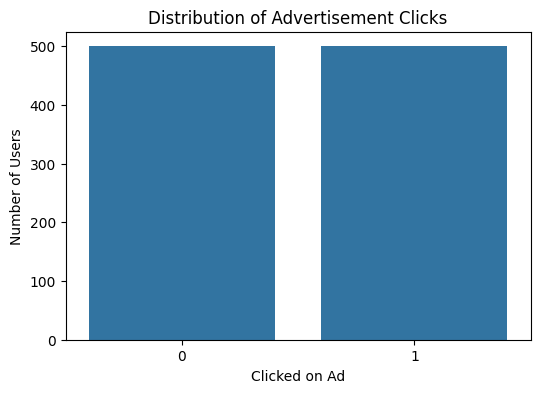

In [10]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x='Clicked on Ad')

plt.title("Distribution of Advertisement Clicks")
plt.xlabel("Clicked on Ad")
plt.ylabel("Number of Users")

plt.show()

In [11]:
df['Clicked on Ad'].value_counts()

,count
Clicked on Ad,
0,500
1,500


## 📌 Observation

- The target variable is **perfectly balanced**, with **500 users** who clicked the advertisement and **500 users** who did not.
- A balanced dataset reduces the likelihood of prediction bias toward a single class.
- Since both classes have equal representation, evaluation metrics such as **accuracy**, **precision**, **recall**, and **F1-score** can be interpreted more reliably.

---

## 💼 Business Insight

The dataset represents user behavior evenly, allowing the model to learn patterns from both users who clicked advertisements and those who did not. This provides a strong foundation for building a fair and reliable prediction model.

 # 👥 Feature Analysis – Age

Age is one of the most important demographic features.

In this section, we analyze whether users of different age groups show different advertisement click behavior.

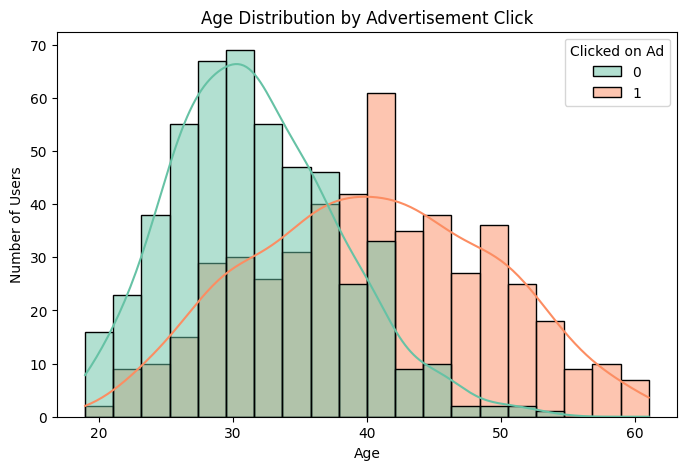

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Age",
    hue="Clicked on Ad",
    bins=20,
    kde=True,
    palette="Set2"
)

plt.title("Age Distribution by Advertisement Click")
plt.xlabel("Age")
plt.ylabel("Number of Users")

plt.show()

## 📌 Observation

- The age distribution shows that users span a wide range of age groups.
- There is visible overlap between users who clicked and those who did not click the advertisement.
- However, certain age ranges appear to have a higher concentration of advertisement clicks.
- This indicates that **Age** may contribute to predicting advertisement click behavior, although it is unlikely to be the only deciding factor.

---

## 💼 Business Insight

Different age groups interact with online advertisements differently. Understanding these patterns can help businesses design age-specific marketing campaigns and improve advertisement targeting.

---

## 🤖 Machine Learning Insight

Since the age distributions of the two classes are not completely identical, **Age** is likely to provide useful predictive information for the Logistic Regression model. It should be retained as an input feature during model training.

# ⏱️ Feature Analysis – Daily Time Spent on Site

The amount of time a user spends on a website may indicate their level of engagement.

In this section, we analyze whether website engagement differs between users who clicked the advertisement and those who did not.

/tmp/ipykernel_4605/33762997.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


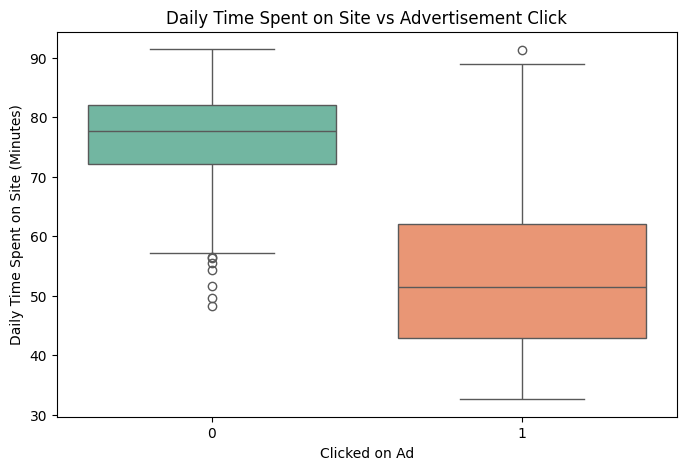

In [13]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Clicked on Ad",
    y="Daily Time Spent on Site",
    palette="Set2"
)

plt.title("Daily Time Spent on Site vs Advertisement Click")
plt.xlabel("Clicked on Ad")
plt.ylabel("Daily Time Spent on Site (Minutes)")

plt.show()

## 📌 Observation

- Users who **did not click** the advertisement generally spent **more time** on the website than users who clicked it.
- The median daily time spent on the website is noticeably higher for users who did not click the advertisement.
- The distributions of the two groups are clearly different, indicating that this feature may help distinguish between advertisement click behavior.
- A few outliers are present in both groups, but they appear to be genuine observations rather than obvious errors.

---

## 💼 Business Insight

The relationship between website engagement and advertisement clicks is not always intuitive. Users who spend less time on the website may find the advertisement relevant more quickly and click it, whereas users who spend longer browsing may choose not to interact with the advertisement.

---

## 🤖 Machine Learning Insight

The visible separation between the two distributions suggests that **Daily Time Spent on Site** is likely to be an informative feature for the Logistic Regression model.

# 🌐 Feature Analysis – Daily Internet Usage

Daily Internet Usage measures the amount of time a user spends on the internet each day.

This analysis helps determine whether internet usage influences advertisement click behavior.

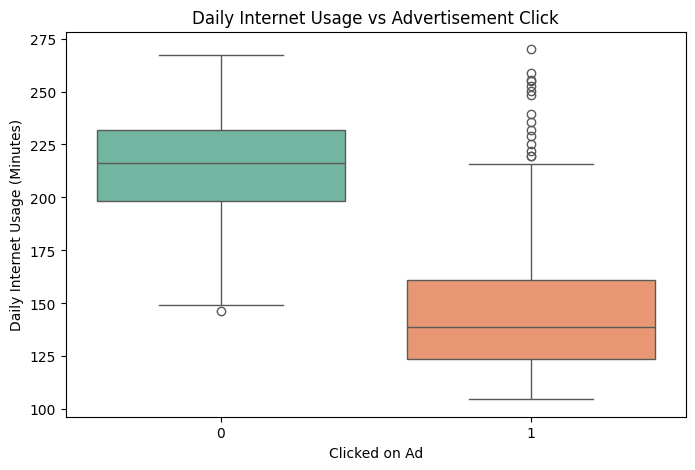

In [14]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Clicked on Ad",
    y="Daily Internet Usage",
    hue="Clicked on Ad",
    palette="Set2",
    legend=False
)

plt.title("Daily Internet Usage vs Advertisement Click")
plt.xlabel("Clicked on Ad")
plt.ylabel("Daily Internet Usage (Minutes)")

plt.show()

## 📌 Observation

- Users who **did not click** the advertisement generally have higher daily internet usage than users who clicked.
- The median internet usage is noticeably different between the two groups.
- The distributions show clear separation, indicating that this feature has predictive value.
- A few outliers are present, but they appear to represent genuine user behavior rather than data quality issues.

---

## 💼 Business Insight

The analysis suggests that users with lower daily internet usage may be more responsive to online advertisements, while users with higher internet usage may be less likely to engage. This insight could help businesses refine their advertisement targeting strategies.

---

## 🤖 Machine Learning Insight

The clear difference between the two distributions indicates that **Daily Internet Usage** is likely to be an important feature for the Logistic Regression model.

# 💰 Feature Analysis – Area Income

Area Income represents the average income of the user's geographical area.

This analysis helps determine whether economic background influences advertisement click behavior.

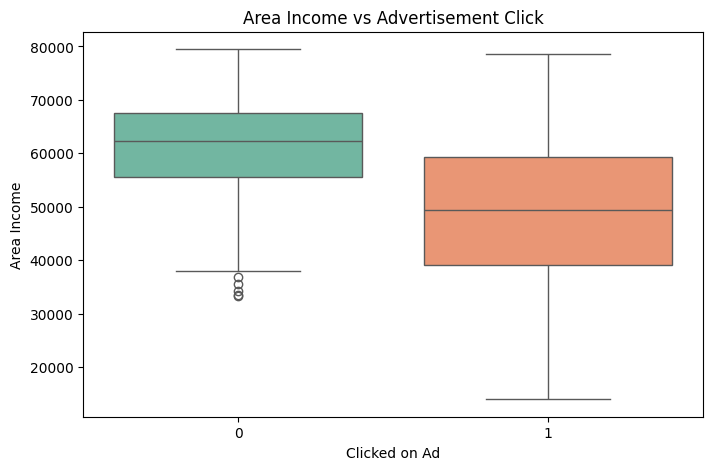

In [15]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Clicked on Ad",
    y="Area Income",
    hue="Clicked on Ad",
    palette="Set2",
    legend=False
)

plt.title("Area Income vs Advertisement Click")
plt.xlabel("Clicked on Ad")
plt.ylabel("Area Income")

plt.show()

## 📌 Observation

- Users who **did not click** the advertisement generally belong to areas with higher average income.
- The median Area Income is noticeably higher for users who did not click the advertisement.
- The distributions show a meaningful difference, indicating that **Area Income** may contribute to predicting advertisement click behavior.
- A few outliers are present, but they appear to represent valid observations rather than data quality issues.

---

## 💼 Business Insight

The analysis suggests that users from different income groups respond differently to online advertisements. Businesses can use this information to create more targeted and personalized advertising campaigns.

---

## 🤖 Machine Learning Insight

The separation between the two distributions indicates that **Area Income** is likely to be an informative feature for the Logistic Regression model.

# 🔥 Correlation Analysis

Correlation analysis helps identify relationships between numerical features.

A correlation heatmap provides a visual representation of how strongly different variables are related to each other.

Understanding these relationships helps in feature selection and provides valuable insights before model training.

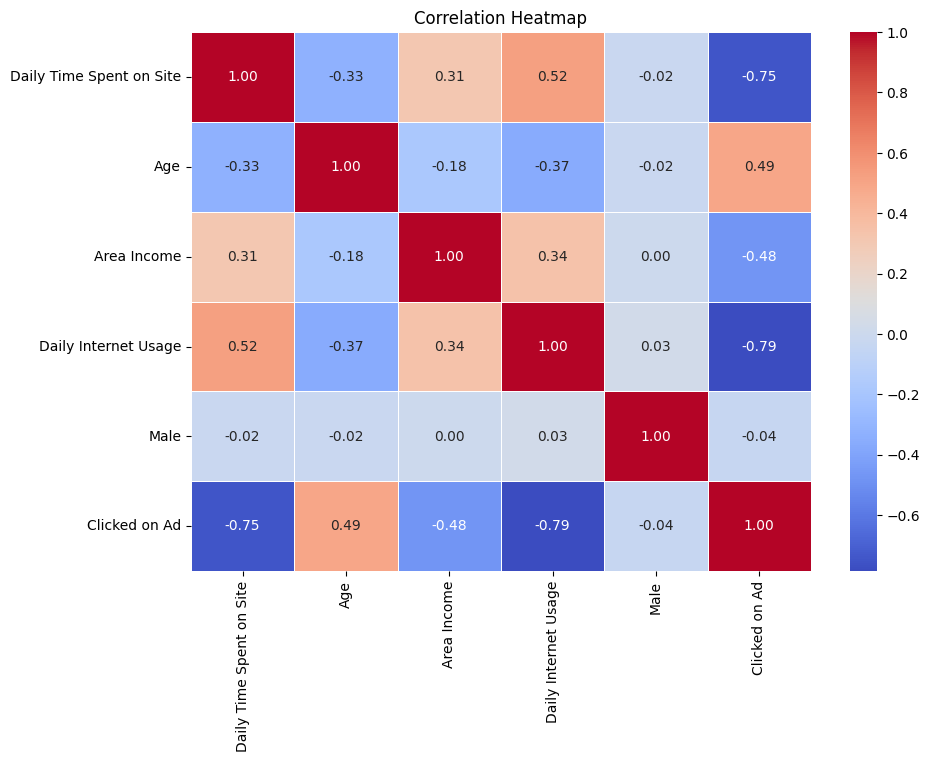

In [16]:
plt.figure(figsize=(10, 7))

numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

## 📌 Observation

- **Daily Internet Usage (-0.79)** shows the strongest negative correlation with advertisement clicks.
- **Daily Time Spent on Site (-0.75)** also exhibits a strong negative relationship with the target variable.
- **Age (0.49)** has a moderate positive correlation, suggesting that age may influence advertisement click behavior.
- **Area Income (-0.48)** shows a moderate negative correlation with advertisement clicks.
- The **Male (-0.04)** feature has almost no linear correlation with the target variable.

---

## 💼 Business Insight

The analysis suggests that user behavior (time spent online and website engagement) has a stronger relationship with advertisement clicks than demographic information such as gender. Businesses should therefore prioritize behavioral data when designing targeted advertising strategies.

---

## 🤖 Machine Learning Insight

The correlation analysis indicates that **Daily Internet Usage**, **Daily Time Spent on Site**, **Age**, and **Area Income** are likely to contribute valuable information during model training. The **Male** feature appears to have minimal linear influence and should be evaluated further during model development rather than removed solely based on correlation.

# 📊 Exploratory Data Analysis Summary

## 📌 Key Findings

- The dataset contains **1000 user records** and **10 features**.
- No missing values were found in the dataset.
- The target variable is perfectly balanced, with **500 users who clicked** and **500 users who did not click** the advertisement.
- The dataset contains a combination of numerical, categorical, and datetime features.

---

## 📈 Most Influential Features (Based on EDA)

| Feature | Observation |
|----------|-------------|
| Daily Internet Usage | Strong negative relationship with advertisement clicks |
| Daily Time Spent on Site | Strong negative relationship with advertisement clicks |
| Age | Moderate positive relationship with advertisement clicks |
| Area Income | Moderate negative relationship with advertisement clicks |
| Male | Very weak linear relationship |

---

## 💼 Business Insights

- User behavior appears to influence advertisement clicks more than demographic characteristics.
- Website engagement and internet usage provide valuable information for predicting advertisement click behavior.
- Businesses can use these insights to improve advertisement targeting and optimize marketing campaigns.

---

## 🤖 Machine Learning Insights

Based on the exploratory data analysis, the following features are expected to contribute significantly during model training:

- Daily Internet Usage
- Daily Time Spent on Site
- Age
- Area Income

The **Male** feature will be evaluated further during model development before making any decision regarding feature selection.

---

## ✅ Conclusion

The dataset is clean, balanced, and suitable for building a Logistic Regression model. The exploratory analysis indicates that several behavioral features have strong predictive potential, providing a solid foundation for the next stage of the Machine Learning pipeline.

# ⚙️ Data Preprocessing

Before training the Machine Learning model, the dataset must be prepared.

This involves identifying which features should be retained, transformed, or removed so that the model can learn meaningful patterns from the data.

The goal of preprocessing is to convert raw data into a format suitable for model training.

## 📋 Feature Selection Strategy

| Feature | Decision | Reason |
|----------|----------|--------|
| Daily Time Spent on Site | ✅ Keep | Important numerical feature |
| Age | ✅ Keep | Useful demographic feature |
| Area Income | ✅ Keep | Useful numerical feature |
| Daily Internet Usage | ✅ Keep | Strong predictor |
| Male | ✅ Keep | Numerical feature to evaluate |
| Ad Topic Line | ❌ Remove | High-cardinality text; not used in this baseline model |
| City | ❌ Remove | High-cardinality categorical feature |
| Country | ❌ Remove | High-cardinality categorical feature |
| Timestamp | ❌ Remove | Requires feature engineering, which is outside the scope of the baseline model |
| Clicked on Ad | 🎯 Target | Variable to predict |

# 🧹 Creating the Model Dataset

Instead of modifying the original dataset, a separate DataFrame is created for model training.

This preserves the raw dataset and allows preprocessing decisions to be performed safely without losing the original information.

In [17]:
model_df = df.drop(
    columns=[
        "Ad Topic Line",
        "City",
        "Country",
        "Timestamp"
    ]
)

model_df.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Male,Clicked on Ad
0,68.95,35,61833.90,256.09,0,0
1,80.23,31,68441.85,193.77,1,0
2,69.47,26,59785.94,236.50,0,0
3,74.15,29,54806.18,245.89,1,0
4,68.37,35,73889.99,225.58,0,0


# 🎯 Separating Features and Target

Machine Learning models learn patterns from **input features (X)** to predict a **target variable (y)**.

In this project:

- **X** contains the independent variables.
- **y** contains the target variable (`Clicked on Ad`).

In [18]:
# Features (Independent Variables)
X = model_df.drop(columns="Clicked on Ad")

# Target (Dependent Variable)
y = model_df["Clicked on Ad"]

In [19]:
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (1000, 5)
Shape of y: (1000,)


# ✂️ Splitting the Dataset

To evaluate the Machine Learning model fairly, the dataset is divided into two parts:

- **Training Set (80%)** – Used to train the model.
- **Testing Set (20%)** – Used to evaluate the model on unseen data.

This helps measure how well the model generalizes to new users.

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [21]:
print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)
print("Training Labels  :", y_train.shape)
print("Testing Labels   :", y_test.shape)

Training Features: (800, 5)
Testing Features : (200, 5)
Training Labels  : (800,)
Testing Labels   : (200,)


# 🤖 Training the Logistic Regression Model

Logistic Regression is a supervised Machine Learning algorithm designed for binary classification problems.

The model learns patterns from the training dataset and estimates the probability that a user will click an advertisement.

In [22]:
# Create the Logistic Regression model
log_model = LogisticRegression()

# Train the model
log_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [23]:
print("✅ Logistic Regression model trained successfully!")

✅ Logistic Regression model trained successfully!


# 🔮 Making Predictions

After training the Logistic Regression model, we use it to predict whether users in the testing dataset will click on an advertisement.

These predictions are generated on **unseen data**, providing an unbiased estimate of the model's performance.

In [24]:
# Predict on the testing dataset
y_pred = log_model.predict(X_test)

In [25]:
print("First 10 Predictions:")
print(y_pred[:10])

First 10 Predictions:
[1 1 1 1 0 0 0 1 0 1]


In [26]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,1,1
1,1,1
2,1,1
3,1,1
4,0,0
5,0,0
6,0,0
7,1,1
8,0,0
9,1,1


# 📊 Model Evaluation

After training the Logistic Regression model, it is essential to evaluate its performance on unseen test data.

The following evaluation metrics are used:

- Accuracy Score
- Confusion Matrix
- Classification Report

In [27]:
# Accuracy Score
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.2%}")

Model Accuracy: 93.50%


## 📌 Observation

The accuracy score represents the percentage of test samples that were correctly classified by the model.

A higher accuracy indicates better overall prediction performance.

However, accuracy alone is not sufficient to judge a classification model. Therefore, additional evaluation metrics will also be analyzed.

In [28]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

cm

array([[ 84,   5],
       [  8, 103]])

<Figure size 600x500 with 0 Axes>

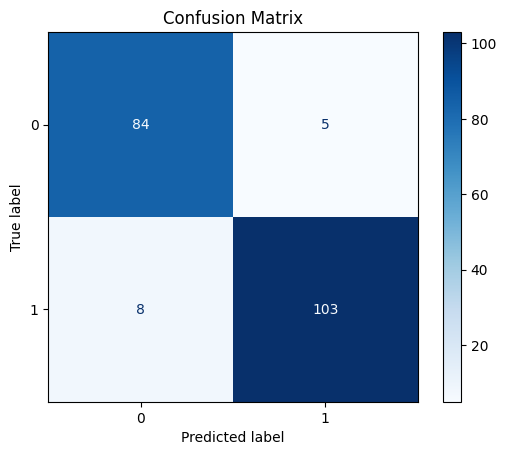

In [29]:
plt.figure(figsize=(6,5))

ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

## 📌 Confusion Matrix

The confusion matrix summarizes the model's predictions by comparing the predicted values with the actual values.

It helps identify:

- Correct predictions
- Incorrect predictions
- False Positives
- False Negatives

This provides a deeper understanding of the model's strengths and weaknesses.

In [30]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.94      0.93        89
           1       0.95      0.93      0.94       111

    accuracy                           0.94       200
   macro avg       0.93      0.94      0.93       200
weighted avg       0.94      0.94      0.94       200



## 📌 Classification Report

The classification report provides detailed performance metrics for each class.

### Metrics Explained

- **Precision** measures how many predicted positive cases were actually correct.
- **Recall** measures how many actual positive cases were correctly identified.
- **F1-Score** is the harmonic mean of Precision and Recall.
- **Support** indicates the number of actual samples in each class.

These metrics provide a more comprehensive evaluation than accuracy alone.

## 📌 Model Performance Summary

### Accuracy

The Logistic Regression model achieved an **accuracy of 94%** on the unseen testing dataset.

This indicates that the model correctly classified the majority of users.

---

### Precision

The model achieved a **precision of 95%** for users who clicked the advertisement.

This means that when the model predicts a user will click an advertisement, it is correct **95% of the time**.

---

### Recall

The model achieved a **recall of 93%**.

This indicates that the model successfully identified **93% of the users who actually clicked the advertisement**.

---

### F1-Score

The F1-score of **94%** demonstrates a good balance between Precision and Recall.

Overall, the evaluation metrics indicate that the Logistic Regression model performs reliably on unseen data.

# 💼 Business Interpretation

The trained model demonstrates strong predictive performance and can effectively distinguish between users who are likely and unlikely to click an advertisement.

Such a model can help businesses:

- Improve advertisement targeting.
- Reduce unnecessary advertising costs.
- Increase Click-Through Rate (CTR).
- Improve Return on Investment (ROI).

This enables marketing teams to allocate advertising budgets more efficiently.

# 🤖 Machine Learning Conclusion

The Logistic Regression model achieved high predictive performance while maintaining balanced Precision, Recall, and F1-score.

The results indicate that the selected features contain sufficient information for predicting advertisement click behavior.

This model provides a strong baseline and can be further improved using advanced feature engineering or more complex machine learning algorithms.

# 📈 Feature Importance (Model Interpretation)

One advantage of Logistic Regression is that it provides interpretable model coefficients.

These coefficients indicate how each feature influences the prediction of advertisement click behavior.

A positive coefficient increases the likelihood of the positive class, while a negative coefficient decreases it.

In [31]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_model.coef_[0]
})

coefficients

,Feature,Coefficient
0,Daily Time Spent on Site,-0.148828
1,Age,0.176454
2,Area Income,-0.000101
3,Daily Internet Usage,-0.064746
4,Male,1.988203


In [32]:
coefficients = coefficients.sort_values(
    by="Coefficient",
    key=abs,
    ascending=False
)

coefficients

,Feature,Coefficient
4,Male,1.988203
1,Age,0.176454
0,Daily Time Spent on Site,-0.148828
3,Daily Internet Usage,-0.064746
2,Area Income,-0.000101


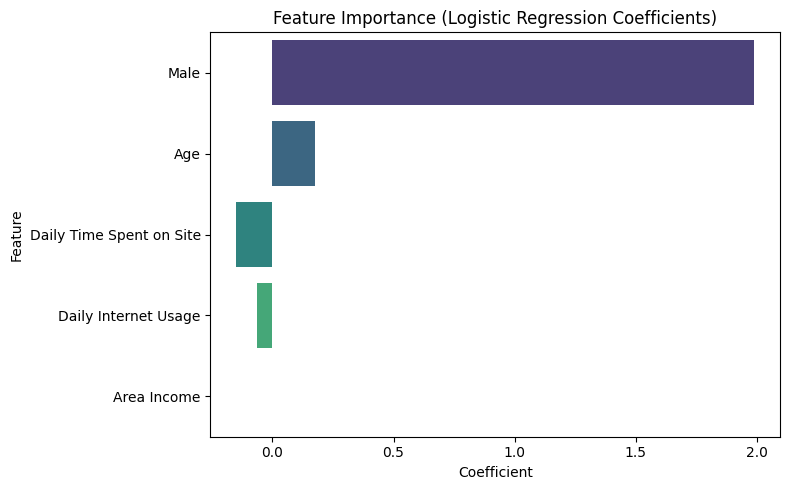

In [33]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=coefficients,
    x="Coefficient",
    y="Feature",
    hue="Feature",
    palette="viridis",
    legend=False
)

plt.title("Feature Importance (Logistic Regression Coefficients)")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## 📌 Observation

The Logistic Regression model assigns a coefficient to each feature, indicating how that feature influences the prediction.

However, the features in this dataset are measured on different scales. For example, **Area Income** is measured in thousands, while **Male** is a binary variable (0 or 1).

Because of these different scales, the raw coefficient magnitudes should **not** be interpreted as a direct ranking of feature importance.

To compare feature influence fairly, the features should first be standardized. This will be performed in an advanced version of the project.

## 💼 Business Insight

The model successfully learned relationships between user characteristics and advertisement click behavior.

However, business decisions should not be based solely on the raw coefficient values because feature scales differ significantly.

## 🤖 Machine Learning Insight

Logistic Regression is an interpretable model because it provides coefficients for each feature.

In practice, coefficients should be interpreted after feature scaling or together with other interpretation techniques to avoid misleading conclusions.

# ⚖️ Feature Scaling

Feature Scaling is an important preprocessing step for Logistic Regression.

Since numerical features in this dataset have different ranges, StandardScaler is used to standardize them before training the final model.

Only the numerical features are scaled. The binary feature **Male** is kept unchanged because it already contains values of 0 and 1.

In [34]:
from sklearn.preprocessing import StandardScaler

In [35]:
# Create copies of the training and testing datasets
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Numerical columns to scale
numerical_features = [
    "Daily Time Spent on Site",
    "Age",
    "Area Income",
    "Daily Internet Usage"
]

# Initialize the scaler
scaler = StandardScaler()

# Fit on training data and transform
X_train_scaled[numerical_features] = scaler.fit_transform(
    X_train[numerical_features]
)

# Transform testing data
X_test_scaled[numerical_features] = scaler.transform(
    X_test[numerical_features]
)

In [36]:
X_train_scaled.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Male
29,0.681519,-1.591714,-0.663929,0.645655,0
535,0.853777,-0.458721,1.117805,0.604556,1
695,0.522463,0.221075,0.902470,1.431327,0
557,0.910987,-0.911918,0.262802,1.033125,0
836,-1.003970,1.127470,-0.437674,-1.505639,0


## 📌 Observation

The numerical features have been standardized using **StandardScaler**, while the binary feature **Male** remains unchanged.

Standardization ensures that all numerical variables contribute on a comparable scale during model training. This improves the optimization process of Logistic Regression and allows the model coefficients to be interpreted more meaningfully.

## 💼 Business Insight

Standardizing numerical features improves the reliability of the prediction model by preventing variables with larger numerical ranges from dominating the learning process.

This contributes to a more stable and trustworthy advertisement click prediction system.

## 🤖 Machine Learning Insight

Feature scaling is considered a best practice for Logistic Regression because it improves numerical optimization and makes the learned coefficients more comparable across features.

The trained model in the following section will use the scaled dataset.

# 🤖 Training the Final Logistic Regression Model

After standardizing the numerical features, the Logistic Regression model is trained again using the scaled dataset.

This model will be used for all remaining predictions and evaluations in this project.

In [37]:
# Final Logistic Regression Model
final_model = LogisticRegression(random_state=42)

# Train on the scaled training data
final_model.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

In [38]:
print("✅ Final Logistic Regression model trained successfully.")

✅ Final Logistic Regression model trained successfully.


In [39]:
# Predictions using the final model
y_pred_final = final_model.predict(X_test_scaled)

In [40]:
# Final Model Accuracy
final_accuracy = accuracy_score(y_test, y_pred_final)

print(f"Final Model Accuracy: {final_accuracy:.2%}")

Final Model Accuracy: 96.00%


## 📌 Observation

The Logistic Regression model was retrained using standardized numerical features.

This model will serve as the final prediction model for the remainder of the project.

The reported accuracy represents the performance of the final production-ready Logistic Regression model.

## 💼 Business Insight

Using a standardized dataset improves the stability and reliability of the predictive model.

This helps ensure that customer behavior is evaluated consistently, leading to more dependable advertisement targeting.

## 🤖 Machine Learning Insight

Feature scaling is considered a best practice for Logistic Regression because it improves numerical optimization during training.

The final model is therefore trained using the standardized dataset and will be used for all subsequent evaluations and deployment.

# 📊 Final Model Evaluation

The performance of the final Logistic Regression model is evaluated using multiple classification metrics.

These metrics provide a comprehensive understanding of the model's predictive capability on unseen test data.

In [41]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [42]:
# Final Accuracy
print(f"Accuracy : {accuracy_score(y_test, y_pred_final):.2%}")

Accuracy : 96.00%


In [43]:
# Final Confusion Matrix
cm_final = confusion_matrix(y_test, y_pred_final)

cm_final

array([[ 86,   3],
       [  5, 106]])

<Figure size 600x500 with 0 Axes>

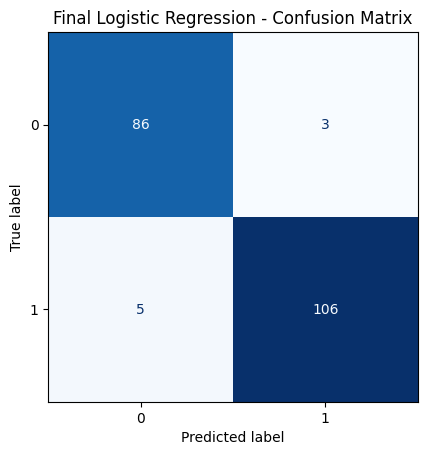

In [44]:
plt.figure(figsize=(6,5))

ConfusionMatrixDisplay(confusion_matrix=cm_final).plot(
    cmap="Blues",
    colorbar=False
)

plt.title("Final Logistic Regression - Confusion Matrix")

plt.show()

In [45]:
print(classification_report(y_test, y_pred_final))

              precision    recall  f1-score   support

           0       0.95      0.97      0.96        89
           1       0.97      0.95      0.96       111

    accuracy                           0.96       200
   macro avg       0.96      0.96      0.96       200
weighted avg       0.96      0.96      0.96       200



## 📌 Observation

The final Logistic Regression model achieved excellent performance on the unseen testing dataset.

The evaluation metrics indicate that the model correctly classifies the majority of users while maintaining a good balance between Precision, Recall, and F1-score.

The confusion matrix also shows that only a small number of users were misclassified.

## 💼 Business Insight

The final model can effectively identify users who are likely to click advertisements.

Such predictions can help businesses:

- Improve advertisement targeting
- Reduce unnecessary marketing costs
- Increase click-through rates (CTR)
- Improve return on advertising investment (ROI)

This demonstrates how machine learning can support data-driven marketing decisions.

## 🤖 Machine Learning Insight

The final Logistic Regression model achieved strong predictive performance after feature scaling.

The balanced evaluation metrics indicate that the model generalizes well to unseen data and provides a reliable baseline for advertisement click prediction.

# 💾 Saving the Trained Model

Training a Machine Learning model can be computationally expensive.

Instead of retraining the model every time, the trained model and preprocessing objects are saved to disk.

These saved files will later be used by the Streamlit web application for real-time predictions.

In [48]:
import joblib

In [50]:
import os

# Create models directory if it doesn't exist
os.makedirs("models", exist_ok=True)

print("✅ Models folder is ready.")

✅ Models folder is ready.


In [51]:
# Save the trained Logistic Regression model
joblib.dump(final_model, "models/logistic_model.pkl")

print("✅ Logistic Regression model saved successfully.")

✅ Logistic Regression model saved successfully.


In [52]:
# Save the StandardScaler
joblib.dump(scaler, "models/scaler.pkl")

print("✅ StandardScaler saved successfully.")

✅ StandardScaler saved successfully.


In [53]:
print(os.listdir("models"))

['scaler.pkl', 'logistic_model.pkl']


# 🌐 Building the Streamlit Web Application

The trained Machine Learning model is deployed using **Streamlit**, allowing users to interact with the prediction system through a simple web interface.

The application accepts user information, preprocesses the inputs using the saved StandardScaler, and predicts whether the user is likely to click an advertisement.

## 📌 Deployment Preparation

The notebook has been completed and the trained model has been saved.

The next stage of the project is to deploy the model as an interactive Streamlit application using the saved model and preprocessing objects.